In [1]:
#check the kernel
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

sys.path.insert(0, '/home/fs01/dy327/venv/nbott/bott')

/home/fs01/dy327/miniconda/envs/bott6/bin/python
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:23:25) [GCC 13.3.0]
sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import glob, os, re
from PIL import Image
from bott.io import load_tif
import torch
from bott.problem import OptimizationProblem
from bott.utils import normalize_arr
from bott.reduction import get_domain_tiles

In [3]:
from matplotlib.colors import TwoSlopeNorm

In [4]:
def map_tiles(hold_fig, hold_ax, hold_arr_tiles,
              hold_true_x_ind, #[thickness_ind, tilt_x_ind] in hold_arr_tiles
              hold_ground_truth_x, 
              hold_1stvar_range, hold_2ndvar_range, 
              hold_arr_pixel_sse, hold_arr_patch_sse,
              hold_arr_epsilon, hold_1stvar_lab, 
              hold_2ndvar_lab, more_text=None): #holder for variables
    '''
    e.g. 1st var: thickness. 2nd var: tilt x
    hold_arr_tiles: [1st var (thickness), 2nd var (tilt x), num_tiles]
    hold_true_x_ind: index of the ground truth in the arr_tiles, e.g. [thickness_ind, tilt_x_ind]
    hold_which_x: indices of which variable from x. [1st var index, 2nd var index]. 
                0 for thickness, 1 for tilt x, 2 for tilt y
    hold_ground_truth_x: actual ground truth values, e.g. [350,2,2]
    '''
    hold_fig.subplots_adjust(hspace=0.4)#, wspace=0.4)
    #plot tiles first
    for ind, axis in enumerate(hold_ax.ravel()[:hold_arr_tiles.shape[2]]):
        cnorm = TwoSlopeNorm(vcenter=0)
        im = axis.imshow( (hold_arr_tiles[:,:,ind]-hold_arr_tiles[hold_true_x_ind[0],
                                                                  hold_true_x_ind[1],
                                                                  ind]).T, #make thickness on x axis
                        cmap='RdBu_r', aspect='auto', norm=cnorm,origin='lower')
        axis.plot(hold_true_x_ind[0], hold_true_x_ind[1], 
                  'kx', markersize=10, markeredgewidth=2)
        axis.set_title(f'Tile {ind}')
        axis.set_xlabel(hold_1stvar_lab)
        axis.set_xticks(np.arange(hold_arr_tiles.shape[0])[1::2], #ticks #from 1st tick, every 2nd
                        hold_1stvar_range[1::2], rotation=45) #labels 
        axis.set_yticks(np.arange(hold_arr_tiles.shape[1])[::2], #ticks #every 2nd
                        hold_2ndvar_range[::2])
        axis.set_ylabel(hold_2ndvar_lab)
        hold_fig.colorbar(im, ax=axis)
        #else: axis.axis('off')

    more_plots = [hold_arr_pixel_sse, hold_arr_patch_sse, hold_arr_epsilon]
    more_plots_titles = ['Pixel-wise SSE', 'Patch-wise SSE', 'Epsilon']
    for ind, axis in enumerate(hold_ax.ravel()[-len(more_plots):]):
        im = axis.imshow(more_plots[ind].T,
                        origin='lower', cmap='jet', aspect='auto')
        axis.set_title(more_plots_titles[ind])
        axis.set_xlabel(hold_1stvar_lab);axis.set_ylabel(hold_2ndvar_lab)
        axis.set_xticks(np.arange(hold_arr_tiles.shape[0])[1::2], #ticks #from 1st tick, every 2nd
                        hold_1stvar_range[1::2], rotation=45) #labels 
        axis.set_yticks(np.arange(hold_arr_tiles.shape[1])[::2], #ticks #every 2nd
                        hold_2ndvar_range[::2])
        hold_fig.colorbar(im, ax=axis)
        axis.plot(hold_true_x_ind[0], hold_true_x_ind[1], 'wx', markersize=10, markeredgewidth=2)

    moreinfo = '' if more_text is None else more_text
    hold_fig.suptitle(f'Ground truth: {hold_ground_truth_x}.'+moreinfo, fontsize=16)

In [5]:
def load_pacbed(x):
    tag = f'./imgs/th{x[0]}_tx{x[1]}_ty{x[2]}.tif'
    return normalize_arr(load_tif(tag), 'zero_to_one')#'standardize ') #np.asarray(Image.open(tag))

### back up functions

In [6]:
import psutil

# Get virtual memory information
mem = psutil.virtual_memory()

# Print details
print(f"Total RAM: {mem.total / (1024**3):.2f} GB")
print(f"Available RAM: {mem.available / (1024**3):.2f} GB")
print(f"Used RAM: {mem.used / (1024**3):.2f} GB")
print(f"RAM Usage Percentage: {mem.percent}%")

Total RAM: 92.78 GB
Available RAM: 3.98 GB
Used RAM: 87.24 GB
RAM Usage Percentage: 95.7%


In [ ]:
img_dir = './imgs/'
img_list = glob.glob(os.path.join(img_dir, '*.tif'))

In [ ]:
len(img_list)

9457

In [7]:
def extract_params_from_filename(path):
    # Use regex to find numeric values after each keyword
    match = re.search(r'th(\d+)_tx(-?\d+)_ty(-?\d+)', path)
    if match:
        thickness = int(match.group(1))
        tiltx = int(match.group(2))
        tilty = int(match.group(3))
        #return torch.tensor([thickness, tiltx, tilty], dtype=torch.float)
        return [thickness, tiltx, tilty]
    else:
        raise ValueError(f"Could not parse path: {path}")

In [8]:
X_total = np.stack([extract_params_from_filename(p) for p in img_list])

In [9]:
X_total.shape

(9457, 3)

In [ ]:
# imgs = defaultdict(lambda: defaultdict(list))

# for th in range(50,1000,50):
#     for tx in range(0,10,1):
#         tag = f'./imgs/th{th}_tx{tx}_ty2.tif'
#         imgs[th][tx] = np.asarray(Image.open(tag))

In [ ]:
#mask conditions 
#get the subset of X using indices
# Define the range conditions
# condition_1 = (X_total[:, 0] >= 350) & (X_total[:, 0] <= 350)  # for variable 1
# condition_2 = (X_total[:, 1] >= 2) & (X_total[:, 1] <= 2)   # for variable 2
# condition_3 = (X_total[:, 2] >= 2) & (X_total[:, 2] <= 2)  # for variable 3

condition_1 =  (X_total[:, 0] == 350)  # for variable 1
condition_2 = (X_total[:, 1] == 2)   # for variable 2
condition_3 =  (X_total[:, 2] == 2)  # for variable 3

# Combine conditions (element-wise AND)
filtered_indices = condition_1 & condition_2 & condition_3

In [ ]:
np.where(filtered_indices)[0][0]

2001

In [ ]:
ground_truth_x = [350,2,2]
ground_truth_x_ind = [np.where(np.arange(50,1000,50)==ground_truth_x[0])[0][0],
                      np.where(np.arange(0,10,1)==ground_truth_x[1])[0][0],
                      np.where(np.arange(0,10,1)==ground_truth_x[2])[0][0]]
print(ground_truth_x_ind)

[6, 2, 2]


### back to the code

```python
for thickness in range(50,1000,50): #20
    for tilt_x in range(0,10,1):
        for tilt_y in range(0,10,1):

for thickness in range(25,1000,50): #20
    for tilt_x in range(-10,10,1):
        for tilt_y in range(-10,10,1):
```

TODOS

0. 350, 2, 2
1. 250, 2, 6
2. 720, 0, 0
3. crop to small angle

[6, 2, 2]


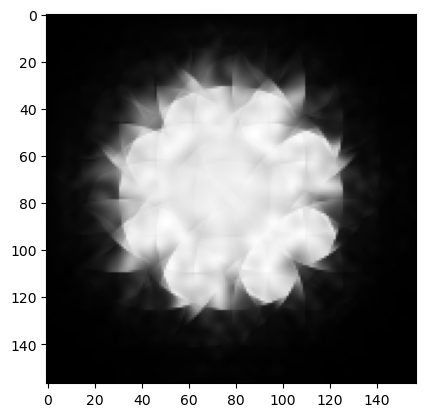

In [6]:
### set up variables
ground_truth_x = [350,2,2]
thickness_range = np.arange(50,1000,50) #19
tilt_x_range = np.arange(0,10,1) #10
tilt_y_range = np.arange(0,10,1)

ground_truth_x_ind = [np.where(thickness_range==ground_truth_x[0])[0][0],
                      np.where(tilt_x_range==ground_truth_x[1])[0][0],
                      np.where(tilt_x_range==ground_truth_x[2])[0][0]]
print(ground_truth_x_ind)

ground_truth = load_pacbed(ground_truth_x)
plt.figure()
plt.imshow(ground_truth,cmap='gray')

In [11]:
print(np.min(ground_truth),np.max(ground_truth))

0.0 1.0


In [7]:
num_sq_tile_1D = 3
num_tiles_total = num_sq_tile_1D**2

In [8]:
# OptimizationProblem would keep all the tensor on the specified device
problem = OptimizationProblem(ground_truth=torch.Tensor(ground_truth),
                              output_path='./output/', 
                              save_results=True, 
                              reduction_params={'reduction_type':'square', 
                                                'reduction_kwargs':{'num_tiles':num_sq_tile_1D}},
                              loss_params={'loss_type':'SSE', 'dp_pow': 1}, 
                              norm_arr=False,
                              dim=3,
                              bounds=[(50,1000), (0, 10), (0,10)],
                              noise_std=0,
                              dtype=torch.float32, 
                              device='cpu'
                              ) # "cpu" or "cuda" for physics simulation

loss_func = problem.loss_func
reduction_true = problem.reduction_true.to(torch.float32) #patch term
measurement_true = problem.measurement_true.to(torch.float32) #ground_truth
sf_tile = problem.scaling_factor
print(sf_tile)

2704


todo: reduction without sse

### 

In [ ]:
#thickness vs. tilt x
arr_tiles = np.zeros((19,10,num_tiles_total))
arr_pixel_sse = np.zeros((19,10))
arr_patch_sse = np.zeros((19,10))
arr_epsilon = np.zeros((19,10))

for ind_th, th in enumerate(thickness_range): #thickness #19
    for ind_tx, tx in enumerate(tilt_x_range): #tilt_x #10
        ## load image to compare with ground truth
        #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
        temp_img = torch.Tensor(load_pacbed([th,tx,2])).to(torch.float32)
        
        temp_pixel_loss = (temp_img-measurement_true).pow(2).sum(dim=(0,1))
        arr_pixel_sse[ind_th,ind_tx] = temp_pixel_loss.numpy()

        temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
        arr_tiles[ind_th,ind_tx,:] = temp_patch.numpy()

        temp_patch_loss = sf_tile* loss_func(y_simu=temp_patch,
                                        y_true=reduction_true,
                                        reduce=False) #working correctly for SSE
        arr_patch_sse[ind_th,ind_tx] = temp_patch_loss.numpy()

        epsilon = temp_pixel_loss - temp_patch_loss
        arr_epsilon[ind_th,ind_tx] = epsilon.numpy()

In [18]:
#tilt y vs. tilt x
arr_tiles2 = np.zeros((10,10,num_tiles_total))
arr_pixel_sse2 = np.zeros((10,10))
arr_patch_sse2 = np.zeros((10,10))
arr_epsilon2 = np.zeros((10,10))

for ind_ty, ty in enumerate(tilt_y_range): #thickness #19
    for ind_tx, tx in enumerate(tilt_x_range): #tilt_x #10
        ## load image to compare with ground truth
        #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
        temp_img = torch.Tensor(load_pacbed([ground_truth_x[0],tx,ty])).to(torch.float32)
        
        temp_pixel_loss = (temp_img-measurement_true).pow(2).sum(dim=(0,1))
        arr_pixel_sse2[ind_ty,ind_tx] = temp_pixel_loss.numpy()

        temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
        arr_tiles2[ind_ty,ind_tx,:] = temp_patch.numpy()

        temp_patch_loss = sf_tile* loss_func(y_simu=temp_patch,
                                        y_true=reduction_true,
                                        reduce=False) #working correctly for SSE
        arr_patch_sse2[ind_ty,ind_tx] = temp_patch_loss.numpy()

        epsilon = temp_pixel_loss - temp_patch_loss
        arr_epsilon2[ind_ty,ind_tx] = epsilon.numpy()

In [23]:
#thickness vs. tilt y
arr_tiles3 = np.zeros((19,10,num_tiles_total))
arr_pixel_sse3 = np.zeros((19,10))
arr_patch_sse3 = np.zeros((19,10))
arr_epsilon3 = np.zeros((19,10))

for ind_th, th in enumerate(thickness_range): #thickness #19
    for ind_ty, ty in enumerate(tilt_y_range): #tilt_x #10
        ## load image to compare with ground truth
        #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
        temp_img = torch.Tensor(load_pacbed([th,2,ty])).to(torch.float32)
        
        temp_pixel_loss = (temp_img-measurement_true).pow(2).sum(dim=(0,1))
        arr_pixel_sse3[ind_th,ind_ty] = temp_pixel_loss.numpy()

        temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
        arr_tiles3[ind_th,ind_ty,:] = temp_patch.numpy()

        temp_patch_loss = sf_tile* loss_func(y_simu=temp_patch,
                                        y_true=reduction_true,
                                        reduce=False) #working correctly for SSE
        arr_patch_sse3[ind_th,ind_ty] = temp_patch_loss.numpy()

        epsilon = temp_pixel_loss - temp_patch_loss
        arr_epsilon3[ind_th,ind_ty] = epsilon.numpy()

### back to plotting

In [12]:
arr_tiles.shape

(19, 10, 9)

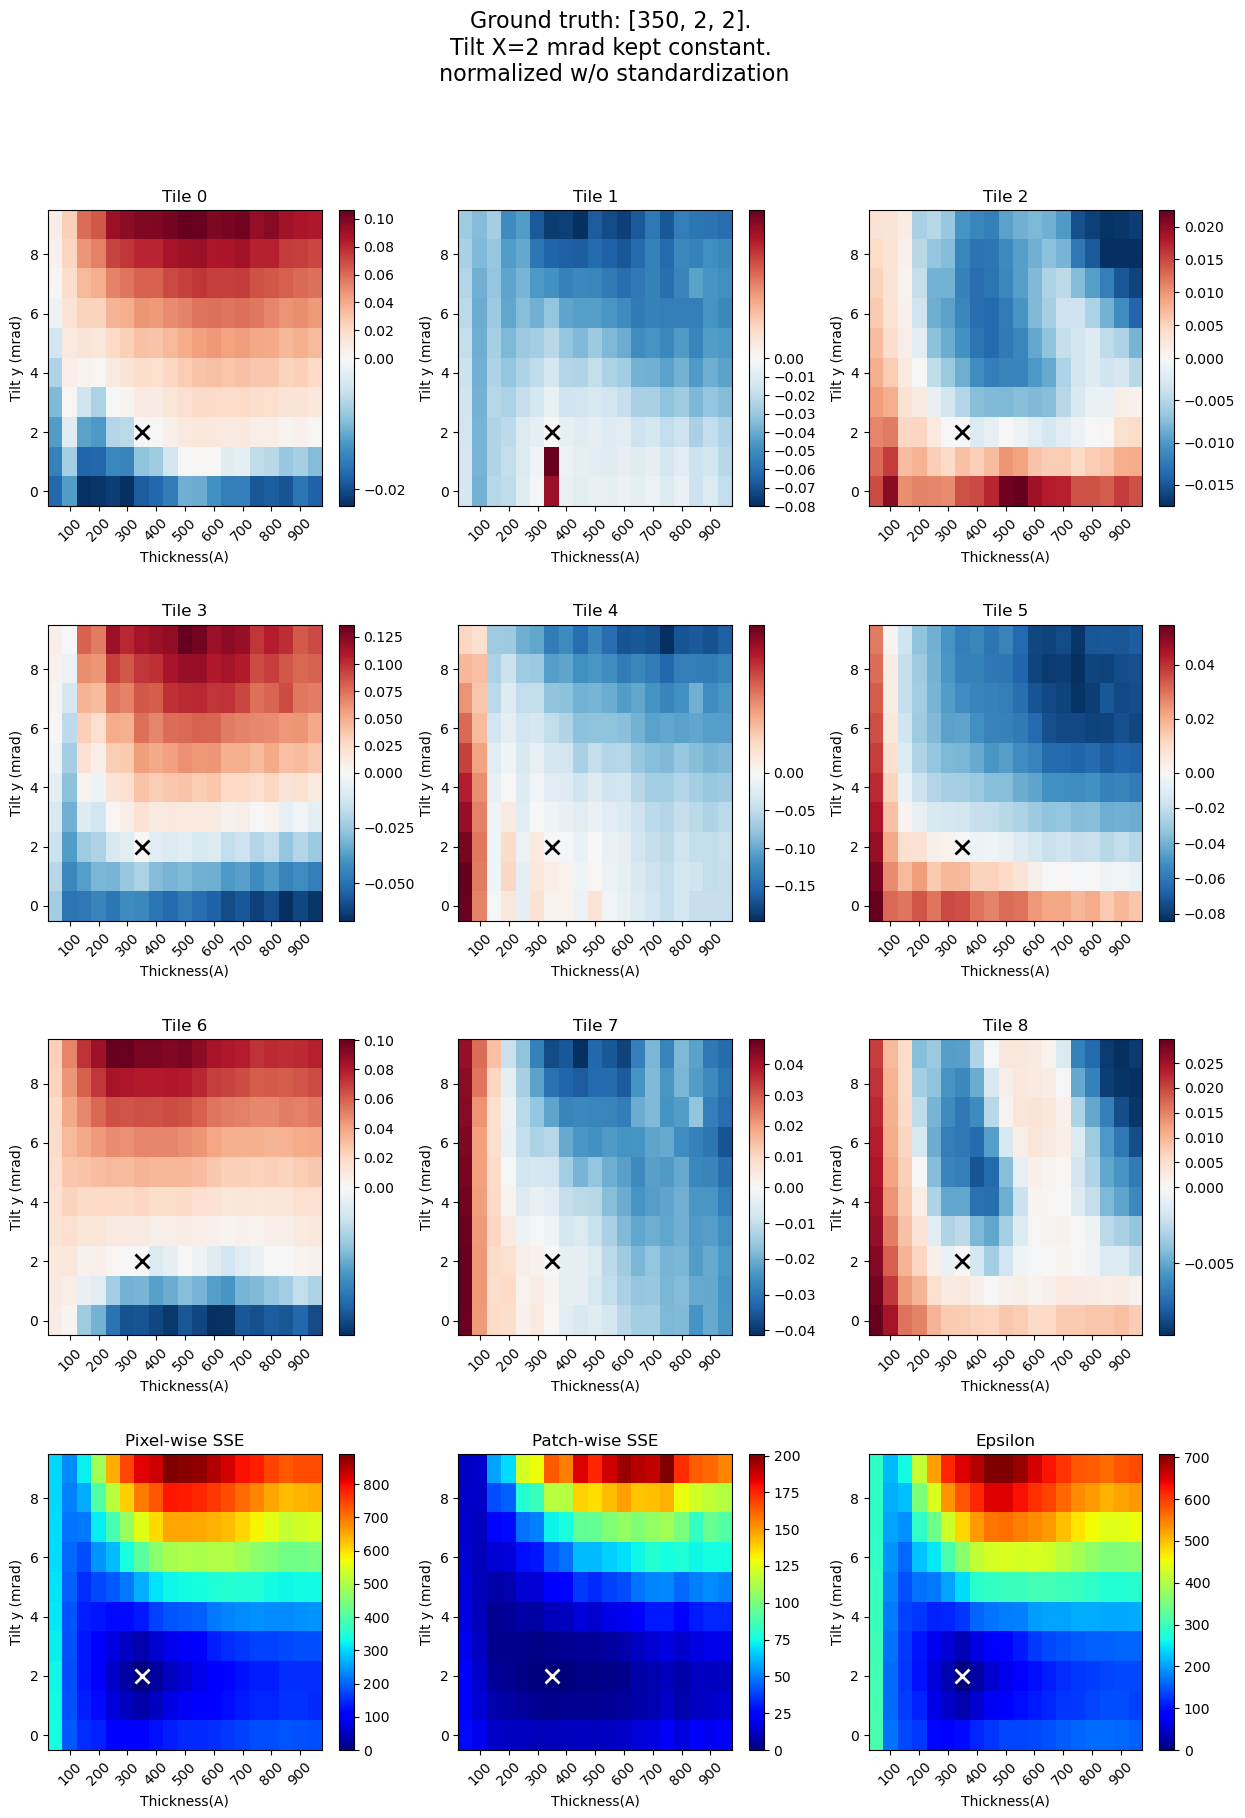

In [25]:
fig,ax = plt.subplots(4,3, figsize=(15,20))
map_tiles(fig,ax,arr_tiles3,[ground_truth_x_ind[0],ground_truth_x_ind[2]],
          ground_truth_x, thickness_range, tilt_y_range,
          arr_pixel_sse3, arr_patch_sse3, arr_epsilon3,
          'Thickness(A)', 'Tilt y (mrad)', 
          more_text=f'\nTilt X={ground_truth_x[1]} mrad kept constant.\n normalized w/o standardization')

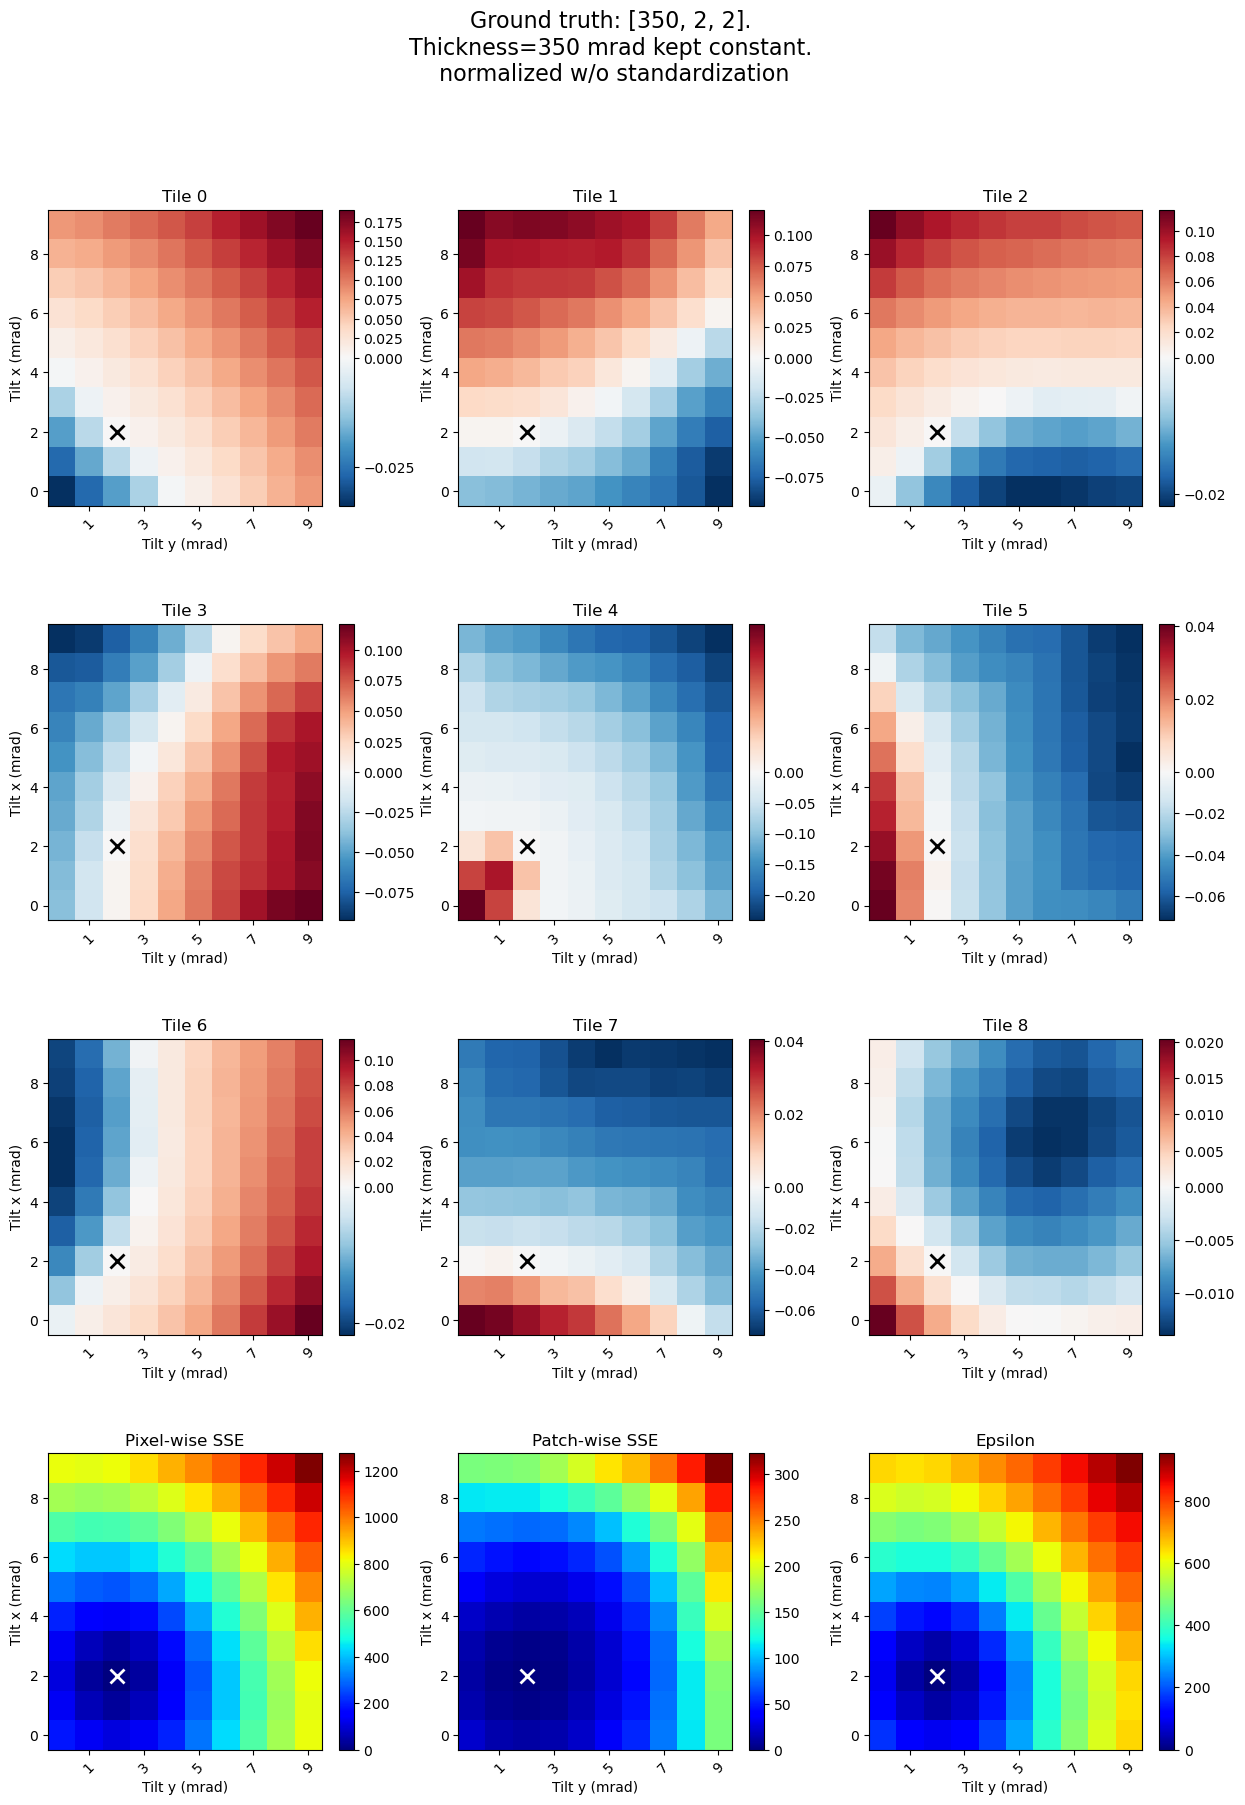

In [20]:
fig,ax = plt.subplots(4,3, figsize=(15,20))
map_tiles(fig,ax,arr_tiles2,[ground_truth_x_ind[2],ground_truth_x_ind[1]],
          ground_truth_x, tilt_y_range, tilt_x_range,
          arr_pixel_sse2, arr_patch_sse2, arr_epsilon2,
          'Tilt y (mrad)', 'Tilt x (mrad)', 
          more_text=f'\nThickness={ground_truth_x[0]} mrad kept constant.\n normalized w/o standardization')

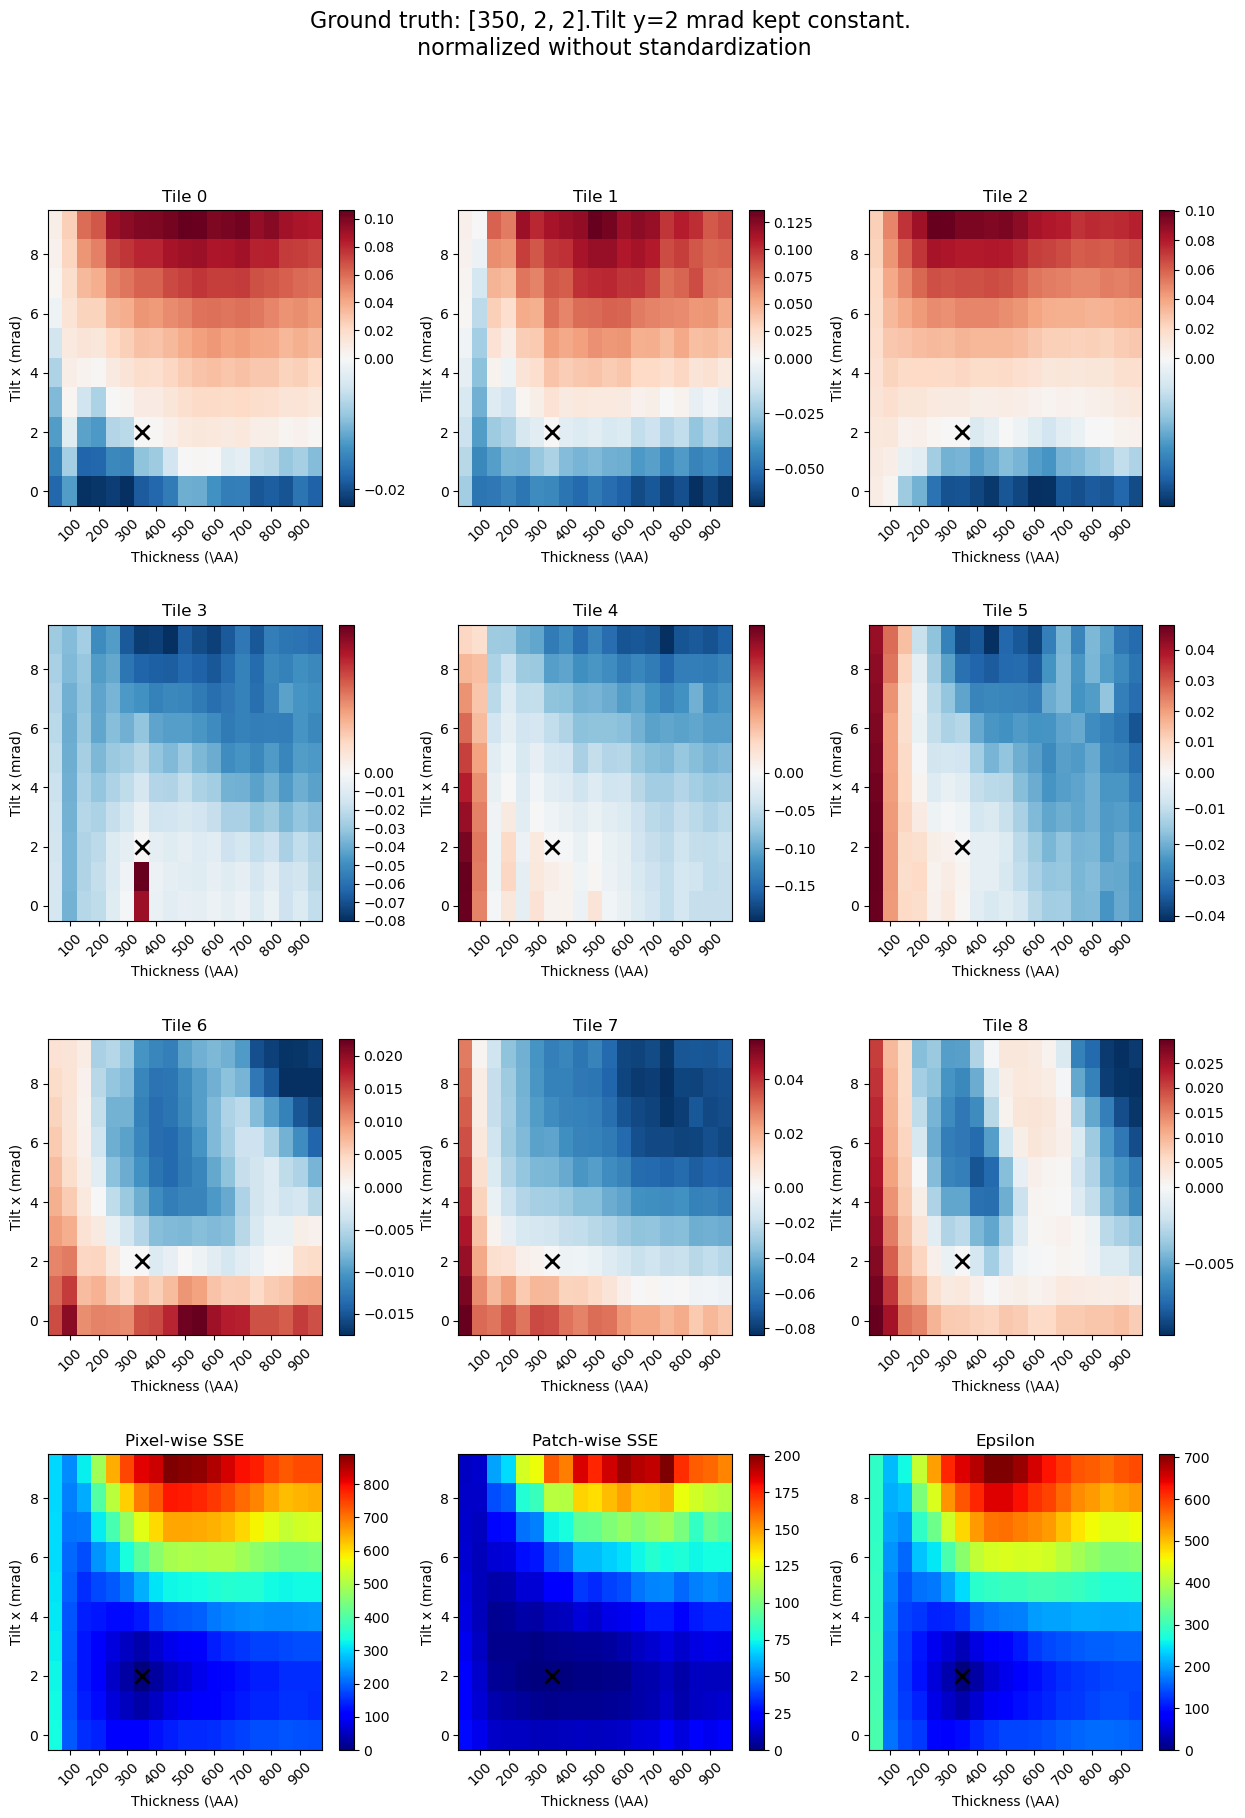

In [33]:
fig,ax = plt.subplots(4,3, figsize=(15,20))
map_tiles(fig,ax,arr_tiles,[ground_truth_x_ind[0],ground_truth_x_ind[1]],
          ground_truth_x,thickness_range, tilt_x_range,
          arr_pixel_sse, arr_patch_sse, arr_epsilon,
          'Thickness (\AA)', 'Tilt x (mrad)', 
          more_text=f'Tilt y={ground_truth_x[2]} mrad kept constant.\n normalized without standardization')

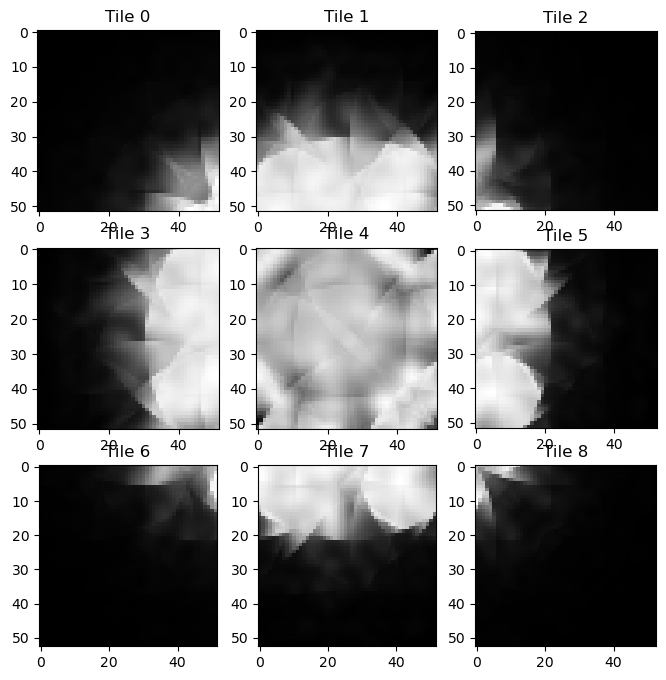

In [16]:
from bott.reduction import get_square_tiles
temp = get_square_tiles(ground_truth,num_tiles=num_sq_tile_1D,
                        reduce=False)
fig,ax = plt.subplots(num_sq_tile_1D,num_sq_tile_1D, figsize=(8,8))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(temp[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

### contour plot

In [9]:
#thickness vs. tilt y
arr_tiles_3D = np.zeros((19,10,10,num_tiles_total))
arr_pixel_sse_3D = np.zeros((19,10,10))
arr_patch_sse_3D = np.zeros((19,10,10))
arr_epsilon_3D = np.zeros((19,10,10))

for ind_th, th in enumerate(thickness_range): #thickness #19
    for ind_ty, ty in enumerate(tilt_y_range): #tilt_x #10
        for ind_tx, tx in enumerate(tilt_x_range):
            ## load image to compare with ground truth
            #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
            temp_img = torch.Tensor(load_pacbed([th,tx,ty])).to(torch.float32)
            
            temp_pixel_loss = (temp_img-measurement_true).pow(2).sum(dim=(0,1))
            arr_pixel_sse_3D[ind_th,ind_tx,ind_ty] = temp_pixel_loss.numpy()

            temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
            arr_tiles_3D[ind_th,ind_tx, ind_ty,:] = temp_patch.numpy()

            temp_patch_loss = sf_tile* loss_func(y_simu=temp_patch,
                                            y_true=reduction_true,
                                            reduce=False) #working correctly for SSE
            arr_patch_sse_3D[ind_th,ind_tx, ind_ty] = temp_patch_loss.numpy()

            epsilon = temp_pixel_loss - temp_patch_loss
            arr_epsilon_3D[ind_th,ind_tx,ind_ty] = epsilon.numpy()

In [ ]:
np.savez('3D_th_tx_ty_3x3', arr_tiles_3D=arr_tiles_3D)

## archive

In [11]:
tiles = get_domain_tiles(torch.Tensor(load_pacbed(ground_truth_x)),0.31,reduce=False)

In [14]:
tiles.shape

torch.Size([1, 5, 157, 157])

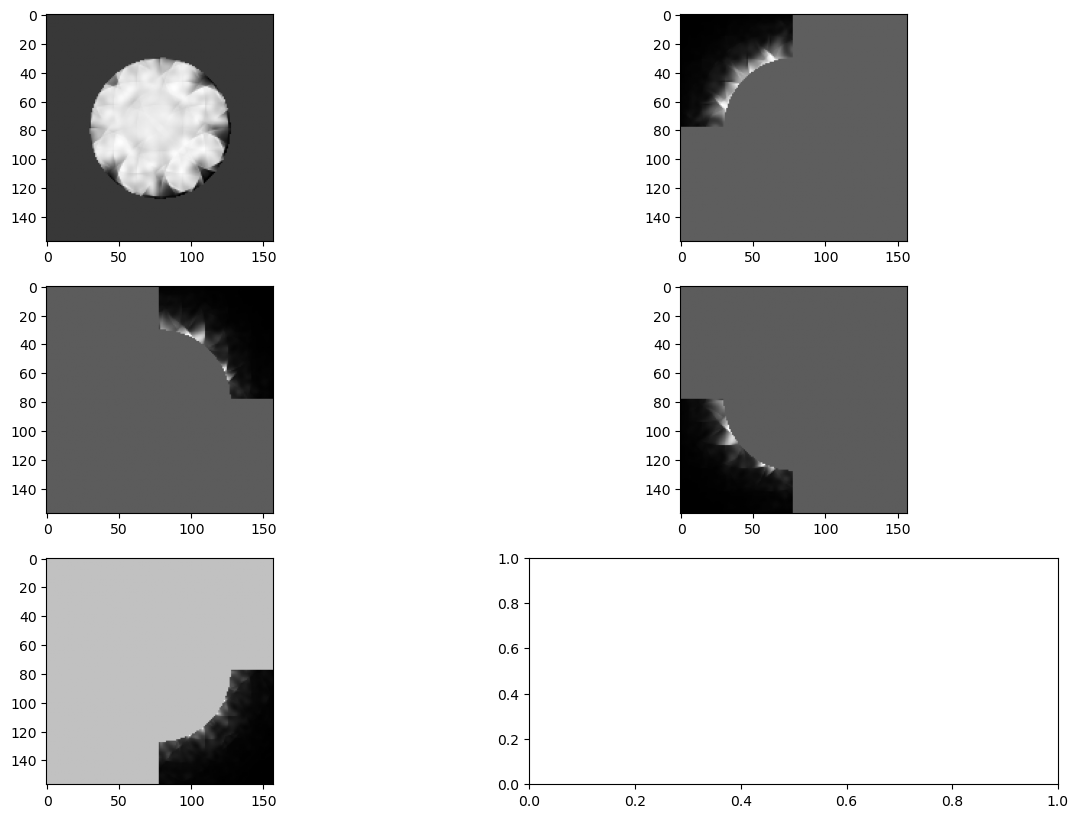

In [ ]:
fig,ax = plt.subplots(3,2,figsize=(15,10))
for i,axis in enumerate(ax.ravel()[:-1]):
    axis.imshow(tiles[0,i,:,:],cmap='gray')


In [110]:
ground_truth.shape[0]//sq_tile_width

52

In [20]:
from bott.reduction import get_square_tiles

In [113]:
temp = get_square_tiles(ground_truth,num_tiles=sq_tile_width,
                        reduce=False)

In [120]:
tiles5 = get_square_tiles(ground_truth,num_tiles=5,
                        reduce=False)

In [21]:
tiles7 = get_square_tiles(ground_truth,num_tiles=7,
                        reduce=False)

In [116]:
temp[0].shape

torch.Size([52, 52])

In [117]:
len(temp)

9

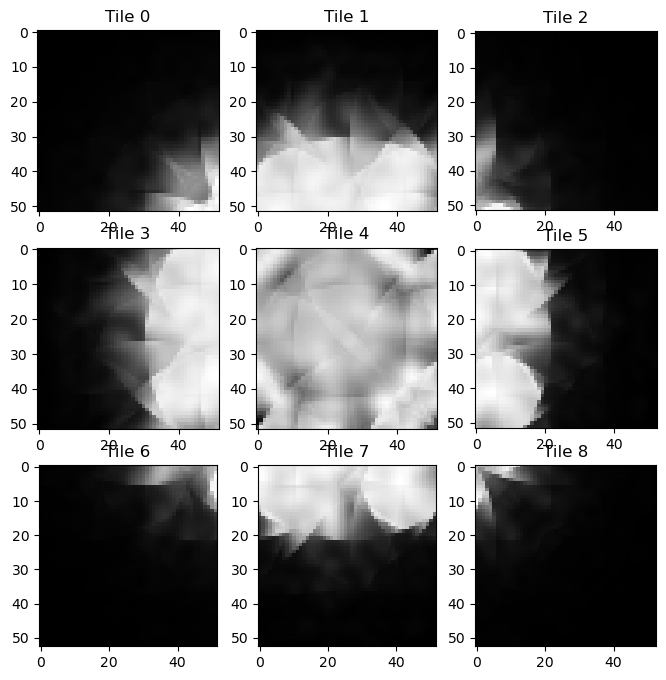

In [119]:
fig,ax = plt.subplots(sq_tile_width,sq_tile_width, figsize=(8,8))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(temp[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

In [25]:
4/9

0.4444444444444444

In [23]:
16/25

0.64

In [24]:
24/49

0.4897959183673469

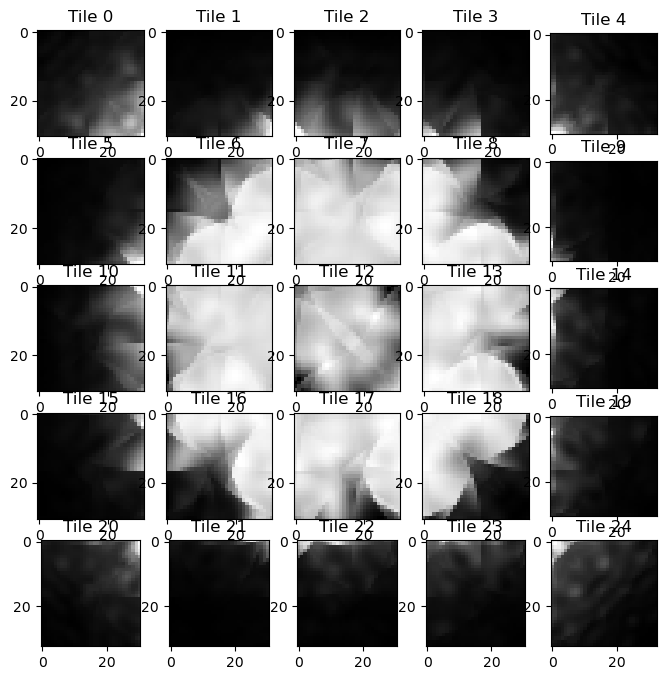

In [121]:
fig,ax = plt.subplots(5,5, figsize=(8,8))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(tiles5[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

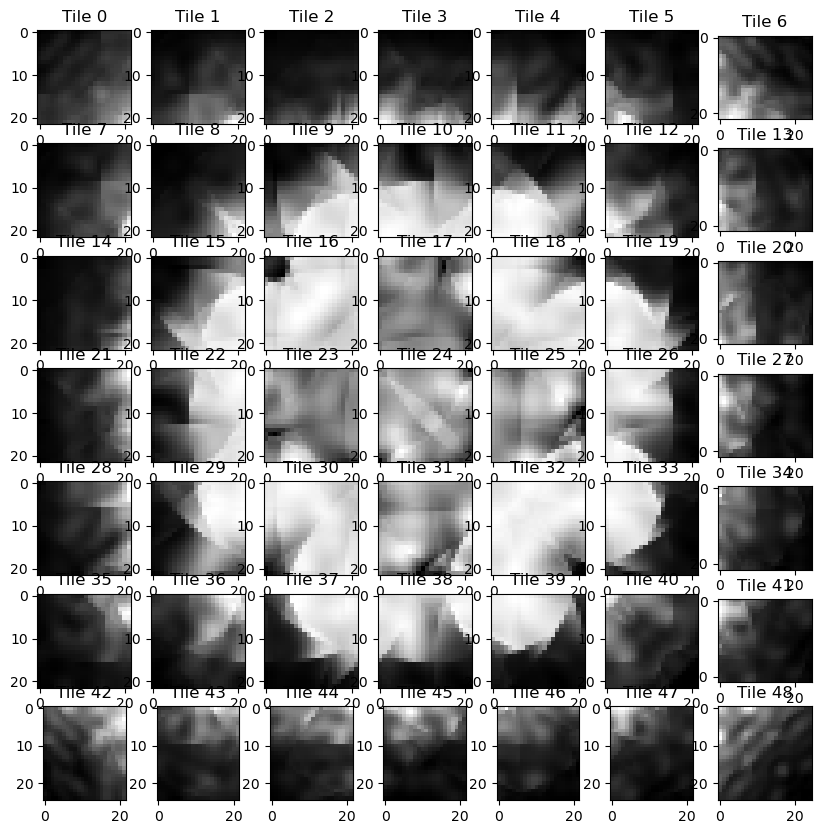

In [22]:
fig,ax = plt.subplots(7,7, figsize=(10,10))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(tiles7[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

In [123]:
import importlib

In [125]:
#importlib.reload(bott.utils)
from bott.utils import create_circular_mask